# Speech-Based Emotion Recognition with Mood-Based Music Recommendation and Visual Dashboard.
The emotions we're trying to detect: neutral, calm, happy, sad, angry, fear, disgust, pleasant surprise (ps) and boredom.

## Setup & Imports

In [49]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import pickle
import joblib
import json
import warnings
from collections import Counter
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("All imports successful!")

All imports successful!


## Constants & Configuration

In [50]:
EMOTIONS = ["neutral", "calm", "happy", "sad", "angry", "fear", "disgust", "ps", "boredom"]
SAMPLE_RATE = 22050
DURATION = 3
N_MFCC = 40
N_MELS = 128
HOP_LENGTH = 512

DATA_PATH = "data"
MODELS_DIR = "models"
RESULTS_DIR = "results"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Data path:    {os.path.abspath(DATA_PATH)}")
print(f"Models dir:   {os.path.abspath(MODELS_DIR)}")
print(f"Results dir:  {os.path.abspath(RESULTS_DIR)}")

Data path:    /Users/salmanshariff/Desktop/FAI/emotion_recognition_project/data
Models dir:   /Users/salmanshariff/Desktop/FAI/emotion_recognition_project/models
Results dir:  /Users/salmanshariff/Desktop/FAI/emotion_recognition_project/results


## Feature Extraction
This is the heart of the project. We pull out 218 different features from each audio clip.

In [51]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        target_len = SAMPLE_RATE * DURATION
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        else:
            audio = audio[:target_len]

        features = []

        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        features.extend(np.mean(mfccs.T, axis=0))
        features.extend(np.std(mfccs.T, axis=0))

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
        features.extend(np.mean(mel_spec.T, axis=0)[:20])
        features.extend(np.std(mel_spec.T, axis=0)[:20])

        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=HOP_LENGTH)
        features.extend(np.mean(chroma.T, axis=0))
        features.extend(np.std(chroma.T, axis=0))

        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
        features.extend(np.mean(contrast.T, axis=0))
        features.extend(np.std(contrast.T, axis=0))

        tonnetz = librosa.feature.tonnetz(y=audio, sr=sr)
        features.extend(np.mean(tonnetz.T, axis=0))
        features.extend(np.std(tonnetz.T, axis=0))

        zcr = librosa.feature.zero_crossing_rate(audio)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))

        rms = librosa.feature.rms(y=audio)
        features.append(np.mean(rms))
        features.append(np.std(rms))

        centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        features.append(np.mean(centroid))
        features.append(np.std(centroid))

        bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        features.append(np.mean(bandwidth))
        features.append(np.std(bandwidth))

        rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        features.append(np.mean(rolloff))
        features.append(np.std(rolloff))

        try:
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, threshold=0.1)
            pitch_vals = []
            for t in range(pitches.shape[1]):
                idx = magnitudes[:, t].argmax()
                p = pitches[idx, t]
                if p > 0:
                    pitch_vals.append(p)
            if len(pitch_vals) > 0:
                pv = np.array(pitch_vals)
                features.append(np.mean(pv))
                features.append(np.std(pv))
                features.append(np.median(pv))
                features.append(np.max(pv) - np.min(pv))
                pd_diff = np.diff(pv)
                features.append(np.mean(np.abs(pd_diff)))
                features.append(np.std(pd_diff))
            else:
                features.extend([0] * 6)
        except:
            features.extend([0] * 6)

        try:
            y_harm, y_perc = librosa.effects.hpss(audio)
            features.append(np.sum(np.abs(y_harm)) / (np.sum(np.abs(audio)) + 1e-10))
            h_e = np.sum(y_harm**2)
            p_e = np.sum(y_perc**2)
            features.append(h_e / (h_e + p_e + 1e-10))
        except:
            features.extend([0] * 2)

        try:
            fft_mag = np.abs(np.fft.fft(audio)[:len(audio)//2])
            freqs = np.fft.fftfreq(len(audio), 1/sr)[:len(fft_mag)]
            peaks, _ = find_peaks(fft_mag, height=np.max(fft_mag)*0.1, distance=100)
            if len(peaks) > 0:
                pf = freqs[peaks]
                for i in range(min(3, len(pf))):
                    features.append(pf[i])
                features.extend([0] * max(0, 3 - len(pf)))
            else:
                features.extend([0] * 3)
        except:
            features.extend([0] * 3)

        try:
            frames_e = []
            for i in range(0, len(audio) - 2048, 512):
                frames_e.append(np.sum(audio[i:i+2048]**2))
            if len(frames_e) > 1:
                fe = np.array(frames_e)
                features.append(np.std(fe) / (np.mean(fe) + 1e-10))
                features.append(np.polyfit(range(len(fe)), fe, 1)[0] if len(fe) > 2 else 0)
            else:
                features.extend([0] * 2)
        except:
            features.extend([0] * 2)

        try:
            stft_mag = np.abs(librosa.stft(audio, hop_length=HOP_LENGTH))
            flux = np.sum(np.diff(stft_mag, axis=1)**2, axis=0)
            features.append(np.mean(flux))
            features.append(np.std(flux))
        except:
            features.extend([0] * 2)

        try:
            zcr_f = librosa.feature.zero_crossing_rate(audio, frame_length=2048, hop_length=512)[0]
            features.append(np.std(zcr_f) / (np.mean(zcr_f) + 1e-10) if len(zcr_f) > 1 else 0)
            rms_f = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
            features.append(np.std(rms_f) / (np.mean(rms_f) + 1e-10) if len(rms_f) > 1 else 0)
        except:
            features.extend([0] * 2)

        try:
            cf = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
            features.append(np.std(cf) / (np.mean(cf) + 1e-10) if len(cf) > 1 else 0)
        except:
            features.append(0)

        try:
            onsets = librosa.onset.onset_detect(y=audio, sr=sr, units='time')
            if len(onsets) > 0:
                os_str = librosa.onset.onset_strength(y=audio, sr=sr)
                features.append(np.mean(os_str))
                features.append(np.max(os_str))
                features.append(len(onsets) / DURATION)
                if len(onsets) > 1:
                    oi = np.diff(onsets)
                    features.append(np.std(oi) / (np.mean(oi) + 1e-10))
                else:
                    features.append(0)
            else:
                features.extend([0] * 4)
        except:
            features.extend([0] * 4)

        try:
            stft_m = np.abs(librosa.stft(audio, hop_length=HOP_LENGTH))
            fr = librosa.fft_frequencies(sr=sr, n_fft=len(stft_m))
            lo = np.mean(np.sum(stft_m[(fr >= 0) & (fr < 500), :], axis=0))
            mi = np.mean(np.sum(stft_m[(fr >= 500) & (fr < 2000), :], axis=0))
            hi = np.mean(np.sum(stft_m[(fr >= 2000) & (fr < 8000), :], axis=0))
            tot = lo + mi + hi + 1e-10
            features.extend([lo/tot, mi/tot, hi/tot])
            features.append(np.std([lo, mi, hi]) / (np.mean([lo, mi, hi]) + 1e-10))
        except:
            features.extend([0] * 4)

        try:
            stft_m = np.abs(librosa.stft(audio, hop_length=HOP_LENGTH))
            fr = librosa.fft_frequencies(sr=sr, n_fft=len(stft_m))
            env = np.mean(stft_m, axis=1)
            vf = fr[:len(env)]
            vf = vf[vf > 0]
            ve = env[:len(vf)]
            if len(vf) > 1 and np.sum(ve) > 0:
                features.append(np.polyfit(np.log10(vf+1), np.log10(ve+1e-10), 1)[0])
            else:
                features.append(0)
        except:
            features.append(0)

        try:
            rms_r = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
            thr = np.percentile(rms_r, 30)
            features.append(np.sum(rms_r > thr) / len(rms_r))
            if len(rms_r) > 2:
                pk, _ = find_peaks(rms_r, height=thr, distance=5)
                if len(pk) > 1:
                    pi = np.diff(pk)
                    features.append(1.0 / (np.std(pi)/(np.mean(pi)+1e-10) + 1e-10))
                else:
                    features.append(0)
            else:
                features.append(0)
        except:
            features.extend([0] * 2)

        try:
            stft_m = np.abs(librosa.stft(audio, hop_length=HOP_LENGTH))
            ss = [1.0/(np.std(stft_m[:,t])/(np.mean(stft_m[:,t])+1e-10)+1e-10)
                  for t in range(stft_m.shape[1])]
            features.append(np.mean(ss))
            features.append(np.std(ss))
        except:
            features.extend([0] * 2)

        try:
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, threshold=0.1)
            pv2 = []
            for t in range(pitches.shape[1]):
                idx = magnitudes[:, t].argmax()
                p = pitches[idx, t]
                if p > 0:
                    pv2.append(p)
            if len(pv2) > 2:
                pv2 = np.array(pv2)
                features.append(np.polyfit(np.arange(len(pv2)), pv2, 1)[0])
                features.append(1.0/(np.std(pv2)/(np.mean(pv2)+1e-10)+1e-10))
            else:
                features.extend([0] * 2)
        except:
            features.extend([0] * 2)

        try:
            rms_ad = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
            if len(rms_ad) > 10:
                af = int(len(rms_ad)*0.2)
                df = int(len(rms_ad)*0.2)
                ae = np.mean(rms_ad[:af])
                de = np.mean(rms_ad[-df:])
                se = np.mean(rms_ad[af:-df]) if af+df < len(rms_ad) else np.mean(rms_ad)
                t_e = ae + se + de + 1e-10
                features.extend([ae/t_e, se/t_e, de/t_e])
                features.append((rms_ad[af-1]-rms_ad[0])/af if af > 1 else 0)
            else:
                features.extend([0] * 4)
        except:
            features.extend([0] * 4)

        try:
            stft_m = np.abs(librosa.stft(audio, hop_length=HOP_LENGTH))
            fr = librosa.fft_frequencies(sr=sr, n_fft=len(stft_m))
            fb = []
            for t in range(min(10, stft_m.shape[1])):
                sp = stft_m[:, t]
                pk, _ = find_peaks(sp, height=np.max(sp)*0.2, distance=50)
                if len(pk) >= 2:
                    for peak in pk[:2]:
                        hp = sp[peak]/np.sqrt(2)
                        li = np.where(sp[:peak] >= hp)[0]
                        ri = np.where(sp[peak:] >= hp)[0]
                        if len(li) > 0 and len(ri) > 0:
                            fb.append(fr[peak+ri[-1]] - fr[li[0]])
            features.append(np.mean(fb) if fb else 0)
        except:
            features.append(0)

        return np.array(features)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print(f"Feature extraction function ready.")
print(f"Expected features per sample: 218")

Feature extraction function ready.
Expected features per sample: 218


## Dataset Loading
Loading audio files from RAVDESS, TESS, and EMO-DB datasets.

In [ ]:
def load_dataset(data_path=DATA_PATH):
    features, labels = [], []

    # RAVDESS
    ravdess_path = os.path.join(data_path, "RAVDESS")
    print("Processing RAVDESS dataset")
    if os.path.exists(ravdess_path):
        ravdess_count = 0
        emotion_map = {1:'neutral', 2:'calm', 3:'happy', 4:'sad',
                       5:'angry', 6:'fear', 7:'disgust', 8:'ps'}
        for root, dirs, files in os.walk(ravdess_path):
            for f in files:
                if not f.endswith(".wav"):
                    continue
                parts = f.split('-')
                if len(parts) < 3:
                    continue
                try:
                    emo_code = int(parts[2])
                except:
                    continue
                emotion = emotion_map.get(emo_code)
                if emotion is None or emotion not in EMOTIONS:
                    continue
                feat = extract_features(os.path.join(root, f))
                if feat is not None:
                    features.append(feat)
                    labels.append(emotion)
                    ravdess_count += 1
        print(f"  Loaded {ravdess_count} RAVDESS samples")
    else:
        print(f"  RAVDESS not found at {ravdess_path}")

    # TESS
    tess_path = os.path.join(data_path, "TESS")
    print("Processing TESS dataset")
    if os.path.exists(tess_path):
        tess_count = 0
        tess_map = {'angry':'angry','disgust':'disgust','fear':'fear',
                     'happy':'happy','happiness':'happy','pleasant_surprise':'ps',
                     'pleasant':'ps','ps':'ps','surprise':'ps',
                     'sad':'sad','sadness':'sad','neutral':'neutral'}
        for root, dirs, files in os.walk(tess_path):
            for f in files:
                if not f.endswith(".wav"):
                    continue
                folder = os.path.basename(root)
                fl = folder.lower()
                fn = f.lower()
                emo = None
                for k, v in tess_map.items():
                    if k in fl:
                        emo = v
                        break
                if emo is None:
                    for k, v in tess_map.items():
                        if f'_{k}' in fn:
                            emo = v
                            break
                if emo and emo in EMOTIONS:
                    feat = extract_features(os.path.join(root, f))
                    if feat is not None:
                        features.append(feat)
                        labels.append(emo)
                        tess_count += 1
        print(f"  Loaded {tess_count} TESS samples")
    else:
        print(f"  TESS not found at {tess_path}")

    # EMO-DB (Berlin Emotional Speech Database - gives us BOREDOM)
    emodb_path = os.path.join(data_path, "EMO-DB", "wav")
    print("Processing EMO-DB dataset")
    if os.path.exists(emodb_path):
        emodb_count = 0
        emodb_map = {
            'W': 'angry',
            'L': 'boredom',
            'E': 'disgust',
            'A': 'fear',
            'F': 'happy',
            'T': 'sad',
            'N': 'neutral',
        }
        for f in os.listdir(emodb_path):
            if not f.endswith(".wav"):
                continue
            if len(f) >= 7:
                emo_letter = f[5]
                emotion = emodb_map.get(emo_letter)
                if emotion and emotion in EMOTIONS:
                    feat = extract_features(os.path.join(emodb_path, f))
                    if feat is not None:
                        features.append(feat)
                        labels.append(emotion)
                        emodb_count += 1
        print(f"  Loaded {emodb_count} EMO-DB samples")
    else:
        print(f"  EMO-DB not found at {emodb_path}")

    # Custom data
    custom_path = os.path.join(data_path, "custom")
    if os.path.exists(custom_path):
        cc = 0
        for root, dirs, files in os.walk(custom_path):
            for f in files:
                if not f.endswith(".wav"):
                    continue
                for emo in EMOTIONS:
                    if emo in f.lower():
                        feat = extract_features(os.path.join(root, f))
                        if feat is not None:
                            features.append(feat)
                            labels.append(emo)
                            cc += 1
                        break
        if cc > 0:
            print(f"  Loaded {cc} custom samples")

    print(f"\nTotal: {len(features)} samples, {len(set(labels))} emotions")
    return np.array(features), np.array(labels)

In [53]:
X, y = load_dataset()
print(f"\nDataset shape: {X.shape}")
print(f"Features per sample: {X.shape[1]}")

Processing RAVDESS dataset...
  Loaded 2880 RAVDESS samples
Processing TESS dataset...
  Loaded 2800 TESS samples
Processing EMO-DB dataset...
  Loaded 535 EMO-DB samples

Total: 6215 samples, 9 emotions

Dataset shape: (6215, 218)
Features per sample: 218


## Data Exploration

Class Distribution:
  angry             911 samples
  boredom            81 samples
  calm              384 samples
  disgust           830 samples
  fear              853 samples
  happy             855 samples
  neutral           671 samples
  ps                784 samples
  sad               846 samples


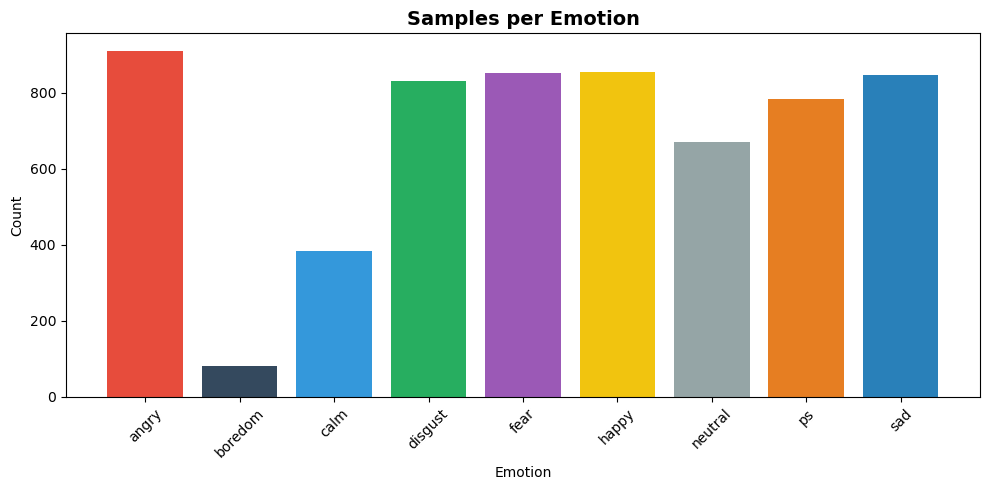

In [54]:
print("Class Distribution:")
unique_emos, counts = np.unique(y, return_counts=True)
for emo, cnt in zip(unique_emos, counts):
    print(f"  {emo:<15} {cnt:>5} samples")

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {'neutral':'#95a5a6','calm':'#3498db','happy':'#f1c40f','sad':'#2980b9',
              'angry':'#e74c3c','fear':'#9b59b6','disgust':'#27ae60','ps':'#e67e22','boredom':'#34495e'}
bar_colors = [colors_map.get(e, '#bdc3c7') for e in unique_emos]
ax.bar(unique_emos, counts, color=bar_colors)
ax.set_title("Samples per Emotion", fontweight='bold', fontsize=14)
ax.set_ylabel("Count")
ax.set_xlabel("Emotion")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "data_exploration.png"), dpi=150, bbox_inches='tight')
plt.show()

## Train/Test Split and Model Training

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Classes: {list(le.classes_)}")

Training set: 4972 samples
Test set:     1243 samples
Classes: [np.str_('angry'), np.str_('boredom'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('ps'), np.str_('sad')]


In [56]:
models = {
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Random_Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500, random_state=42),
    'Gradient_Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"Accuracy: {acc:.4f}")

best_name = max(results, key=lambda x: results[x]['accuracy'])
best_acc = results[best_name]['accuracy']
print(f"\nBest model: {best_name} ({best_acc:.4f})")

Training SVM... Accuracy: 0.9549
Training Random_Forest... Accuracy: 0.9582
Training MLP... Accuracy: 0.9614
Training Gradient_Boosting... Accuracy: 0.9356

Best model: MLP (0.9614)


## Evaluation & Results

In [57]:
print("MODEL RANKINGS")
ranked = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for i, (name, res) in enumerate(ranked, 1):
    print(f"  {i}. {name:<20} {res['accuracy']:.4f}")

MODEL RANKINGS
  1. MLP                  0.9614
  2. Random_Forest        0.9582
  3. SVM                  0.9549
  4. Gradient_Boosting    0.9356


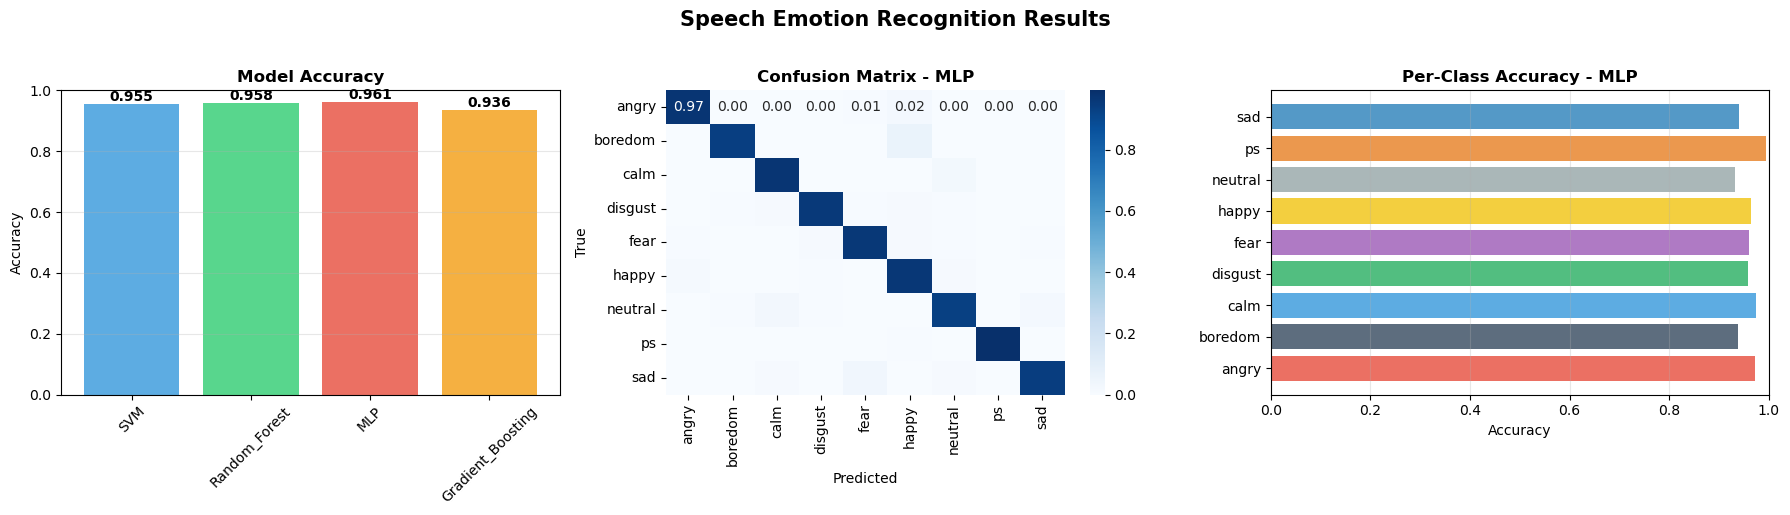

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
accs = [results[m]['accuracy'] for m in model_names]

ax = axes[0]
bars = ax.bar(model_names, accs, color=colors, alpha=0.8)
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{a:.3f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title("Model Accuracy", fontweight='bold')
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
best_pred = results[best_name]['predictions']
cm = confusion_matrix(y_test_encoded, best_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f"Confusion Matrix - {best_name}", fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax = axes[2]
per_class_acc = cm_norm.diagonal()
bar_c = [colors_map.get(e, '#bdc3c7') for e in le.classes_]
ax.barh(le.classes_, per_class_acc, color=bar_c, alpha=0.8)
ax.set_title(f"Per-Class Accuracy - {best_name}", fontweight='bold')
ax.set_xlabel("Accuracy")
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

plt.suptitle("Speech Emotion Recognition Results", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_results.png"), dpi=200, bbox_inches='tight')
plt.show()

In [59]:
print(f"\nClassification Report - {best_name}")
print(classification_report(y_test_encoded, best_pred, target_names=le.classes_, digits=3))


Classification Report - MLP
              precision    recall  f1-score   support

       angry      0.978     0.973     0.975       182
     boredom      0.882     0.938     0.909        16
        calm      0.904     0.974     0.938        77
     disgust      0.975     0.958     0.967       166
        fear      0.953     0.959     0.956       171
       happy      0.943     0.965     0.954       171
     neutral      0.940     0.933     0.936       134
          ps      1.000     0.994     0.997       157
         sad      0.975     0.941     0.958       169

    accuracy                          0.961      1243
   macro avg      0.950     0.959     0.954      1243
weighted avg      0.962     0.961     0.961      1243



## Save Final Model

In [60]:
final_model = results[best_name]['model']

joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.joblib'))
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.joblib'))
joblib.dump(final_model, os.path.join(MODELS_DIR, f'{best_name.lower()}.joblib'))

with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
with open(os.path.join(MODELS_DIR, f'{best_name.lower()}.pkl'), 'wb') as f:
    pickle.dump(final_model, f)

metadata = {
    'emotions': list(le.classes_),
    'n_classes': len(le.classes_),
    'n_features': X.shape[1],
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION,
    'best_model': best_name,
    'test_accuracy': float(best_acc),
    'train_test_split': '80/20',
}
with open(os.path.join(MODELS_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {MODELS_DIR}/:")
for fn in os.listdir(MODELS_DIR):
    print(f"  {fn}")

Saved to models/:
  scaler.pkl
  label_encoder.pkl
  ser_neural_network_model.pkl
  svm.pkl
  svm.joblib
  mlp.joblib
  gradient_boosting.pkl
  metadata.json
  scaler.joblib
  ser_gradient_boosting_model.pkl
  mlp.pkl
  label_encoder.joblib
  gradient_boosting.joblib
  random_forest.joblib
  ser_random_forest_model.pkl
  ser_svm_model.pkl
  random_forest.pkl


## Predict Emotion on a New Audio File

In [61]:
def predict_emotion(audio_path, model=None, scaler=None, label_encoder=None):
    if model is None:
        model = joblib.load(os.path.join(MODELS_DIR, f'{best_name.lower()}.joblib'))
    if scaler is None:
        scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.joblib'))
    if label_encoder is None:
        label_encoder = joblib.load(os.path.join(MODELS_DIR, 'label_encoder.joblib'))

    feat = extract_features(audio_path)
    if feat is None:
        print("Feature extraction failed.")
        return None, None

    expected = scaler.n_features_in_
    if len(feat) < expected:
        feat = np.pad(feat, (0, expected - len(feat)))
    elif len(feat) > expected:
        feat = feat[:expected]

    feat_scaled = scaler.transform(feat.reshape(1, -1))
    probs = model.predict_proba(feat_scaled)[0]
    emotions = label_encoder.classes_
    results = {emo: float(p) for emo, p in zip(emotions, probs)}
    dominant = max(results, key=results.get)
    return results, dominant

Predicted emotion: HAPPY (99.9% confidence)

All probabilities:
  happy          99.9%  ███████████████████████████████████████
  fear            0.1%  
  ps              0.0%  
  sad             0.0%  
  disgust         0.0%  
  neutral         0.0%  
  angry           0.0%  
  boredom         0.0%  
  calm            0.0%  


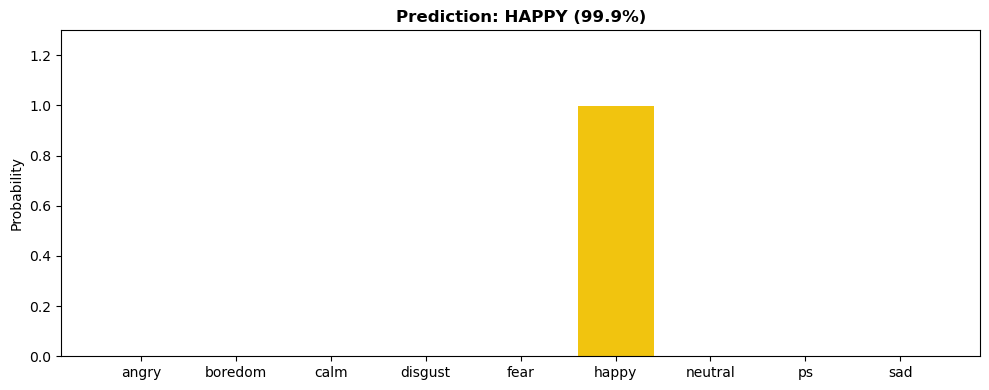

In [62]:
# Change this to an actual .wav file from your data folder
TEST_FILE = "data/EMO-DB/wav/03a01Fa.wav"

if os.path.exists(TEST_FILE):
    res, dominant = predict_emotion(TEST_FILE)
    if res:
        print(f"Predicted emotion: {dominant.upper()} ({res[dominant]*100:.1f}% confidence)\n")
        print("All probabilities:")
        for emo, prob in sorted(res.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(prob * 40)
            print(f"  {emo:<12} {prob*100:>6.1f}%  {bar}")

        fig, ax = plt.subplots(figsize=(10, 4))
        emos = list(res.keys())
        probs_list = [res[e] for e in emos]
        bar_c = [colors_map.get(e, '#bdc3c7') for e in emos]
        ax.bar(emos, probs_list, color=bar_c)
        ax.set_title(f"Prediction: {dominant.upper()} ({res[dominant]*100:.1f}%)", fontweight='bold')
        ax.set_ylabel("Probability")
        ax.set_ylim(0, max(probs_list)*1.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"Test file not found: {TEST_FILE}")
    print("Update the TEST_FILE variable above to point to a real .wav file.")

## Song Recommendation System
Based on whatever emotion the model detects, we recommend songs to uplift the user's mood.

In [63]:
from song_recommender import get_recommendations, format_recommendations, EMOTION_TARGET_PROFILES

for emo in ['happy', 'sad', 'angry', 'fear', 'calm', 'neutral', 'disgust', 'ps', 'boredom']:
    print(f"  Detected Emotion: {emo.upper()}")
    recs = get_recommendations(emo, num_recommendations=5)
    print(format_recommendations(recs))

  Detected Emotion: HAPPY
Song Recommendations:

  1. Can't Stop the Feeling — Justin Timberlake (Pop)  [Match: 99.7%]
  2. Good Vibrations — The Beach Boys (Pop)  [Match: 99.7%]
  3. Walking on Sunshine — Katrina & The Waves (Rock)  [Match: 99.6%]
  4. A Sky Full of Stars — Coldplay (Electronic)  [Match: 99.3%]
  5. Don't Stop Me Now — Queen (Rock)  [Match: 99.3%]
  Detected Emotion: SAD
Song Recommendations:

  1. Can't Stop the Feeling — Justin Timberlake (Pop)  [Match: 99.7%]
  2. Uptown Funk — Bruno Mars (Pop)  [Match: 99.6%]
  3. Walking on Sunshine — Katrina & The Waves (Rock)  [Match: 99.6%]
  4. A Sky Full of Stars — Coldplay (Electronic)  [Match: 99.4%]
  5. Don't Stop Me Now — Queen (Rock)  [Match: 99.3%]
  Detected Emotion: ANGRY
Song Recommendations:

  1. Here Comes the Sun — The Beatles (Rock)  [Match: 99.6%]
  2. Lean On Me — Bill Withers (Soul)  [Match: 99.5%]
  3. Stand by Me — Ben E. King (Soul)  [Match: 99.4%]
  4. Three Little Birds — Bob Marley (Reggae)  [Match: 9

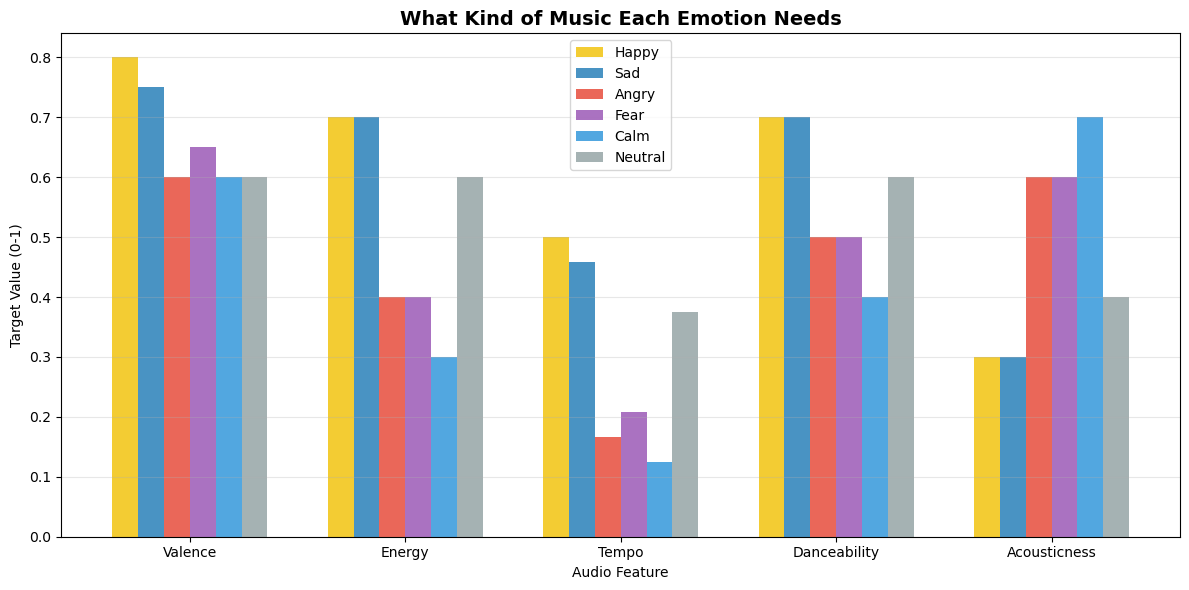

In [64]:
emotions_to_plot = ['happy', 'sad', 'angry', 'fear', 'calm', 'neutral']
features_to_plot = ['valence', 'energy', 'tempo', 'danceability', 'acousticness']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(features_to_plot))
width = 0.12
emo_colors = {'happy':'#f1c40f', 'sad':'#2980b9', 'angry':'#e74c3c',
              'fear':'#9b59b6', 'calm':'#3498db', 'neutral':'#95a5a6'}

for i, emo in enumerate(emotions_to_plot):
    profile = EMOTION_TARGET_PROFILES[emo]
    values = []
    for f in features_to_plot:
        v = profile[f]
        if f == 'tempo':
            v = (v - 60) / 120
        values.append(v)
    ax.bar(x + i * width, values, width, label=emo.capitalize(),
           color=emo_colors.get(emo, '#bdc3c7'), alpha=0.85)

ax.set_xlabel('Audio Feature')
ax.set_ylabel('Target Value (0-1)')
ax.set_title('What Kind of Music Each Emotion Needs', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([f.capitalize() for f in features_to_plot])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mood_profiles.png"), dpi=150, bbox_inches='tight')
plt.show()

In [65]:
demo_emotion = 'sad'
print(f"Demo: If someone sounds {demo_emotion.upper()}, we'd recommend:\n")
recs = get_recommendations(demo_emotion, num_recommendations=5)
print(format_recommendations(recs))

Demo: If someone sounds SAD, we'd recommend:

Song Recommendations:

  1. Can't Stop the Feeling — Justin Timberlake (Pop)  [Match: 99.7%]
  2. Uptown Funk — Bruno Mars (Pop)  [Match: 99.6%]
  3. Walking on Sunshine — Katrina & The Waves (Rock)  [Match: 99.6%]
  4. A Sky Full of Stars — Coldplay (Electronic)  [Match: 99.4%]
  5. Don't Stop Me Now — Queen (Rock)  [Match: 99.3%]
